# Data Exploration - Aletheia Dataset

Initial EDA to understand the distribution of messages, languages, and engagement metrics. This step also handles filtering the corpus for the upcoming semantic search pipeline.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Visualization settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('Dependencies loaded successfully.')

Dependencies loaded successfully.


## Loading data and inspection


In [20]:
# Load dataset
df = pd.read_csv('../timebin_sampled_telegram.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Shape: 64,000 rows × 24 columns


,channel_id,collected_date,date,edit_date,forward_from,forward_from_n_forwards,forward_from_reactions,forward_from_views,is_vaccine_related,language,...,media_url,message_id,n_forwards,reactions,reply_to,text_content,user_id,views,date_parsed,time_bin
0,<CHANNEL_HASH:27401c0ac3256345fb61>,2025-06-15 14:23:38,1583356703000,NaN,NaN,NaN,NaN,NaN,0.0,Portuguese,...,http://noticias.r7.com/saude/menina-de-13-anos...,<CHANNEL_HASH:27401c0ac3256345fb61>_357,15.0,0,NaN,BRASIL: Menina de 13 anos é provável 4º caso d...,<USER_HASH:27401c0ac3256345fb61>,6574.0,2020/03/04 18:18:23,2020/03/01 00:00:00
1,<CHANNEL_HASH:27401c0ac3256345fb61>,2025-06-15 14:21:37,1583117827000,NaN,NaN,NaN,NaN,NaN,0.0,Portuguese,...,314.mp4,<CHANNEL_HASH:27401c0ac3256345fb61>_314,8.0,0,NaN,Os moradores da cidade correm aos supermercados.,<USER_HASH:27401c0ac3256345fb61>,4610.0,2020/03/01 23:57:07,2020/03/01 00:00:00
2,<CHANNEL_HASH:751793d016c8dfbee9d1>,2025-02-22 12:18:56,1585330941000,NaN,NaN,NaN,NaN,NaN,0.0,English,...,NaN,<CHANNEL_HASH:751793d016c8dfbee9d1>_1823,96.0,0,NaN,"🇪🇸 The Spanish government has withdrawn 9,000 ...",<USER_HASH:751793d016c8dfbee9d1>,13592.0,2020/03/27 14:42:21,2020/03/01 00:00:00


In [21]:
# Data types
df.dtypes

channel_id                  object
collected_date              object
date                         int64
edit_date                   object
forward_from                object
forward_from_n_forwards    float64
forward_from_reactions     float64
forward_from_views         float64
is_vaccine_related         float64
language                    object
media_description           object
media_path                  object
media_title                 object
media_type                  object
media_url                   object
message_id                  object
n_forwards                 float64
reactions                    int64
reply_to                    object
text_content                object
user_id                     object
views                      float64
date_parsed                 object
time_bin                    object
dtype: object

In [22]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False)
print(f'Columns with missing values: {len(missing_df)} out of {len(df.columns)}')
missing_df

Columns with missing values: 15 out of 24


,missing,pct
media_description,58510,91.4
forward_from_n_forwards,56402,88.1
forward_from_reactions,56376,88.1
forward_from_views,56402,88.1
forward_from,54630,85.4
reply_to,49087,76.7
media_path,40275,62.9
media_url,34467,53.9
media_title,34171,53.4
media_type,33654,52.6


## 2. Key Variable Distributions

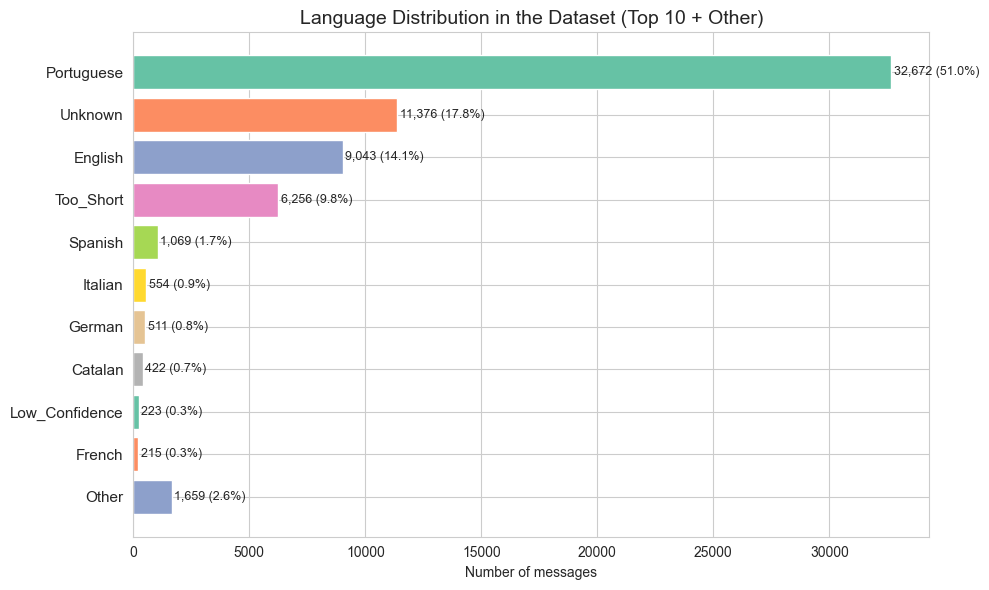

In [23]:
# Language distribution (top 10)
fig, ax = plt.subplots(figsize=(10, 6))
lang_counts = df['language'].value_counts()
top_langs = lang_counts.head(10)
other_count = lang_counts.iloc[10:].sum() if len(lang_counts) > 10 else 0
if other_count > 0:
    top_langs = pd.concat([top_langs, pd.Series({'Other': other_count})])

bars = ax.barh(range(len(top_langs)), top_langs.values, color=sns.color_palette('Set2', len(top_langs)))
ax.set_yticks(range(len(top_langs)))
ax.set_yticklabels(top_langs.index, fontsize=11)
ax.invert_yaxis()
ax.set_title('Language Distribution in the Dataset (Top 10 + Other)', fontsize=14)
ax.set_xlabel('Number of messages')
for i, v in enumerate(top_langs.values):
    ax.text(v + 100, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/01_languages.png', dpi=150, bbox_inches='tight')
plt.show()

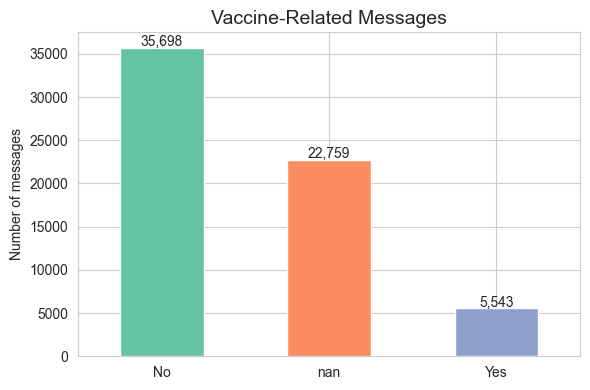

In [24]:
# Vaccine-related messages distribution
fig, ax = plt.subplots(figsize=(6, 4))
vax_counts = df['is_vaccine_related'].value_counts(dropna=False).rename({0.0: 'No', 1.0: 'Yes', np.nan: 'N/A'})
vax_counts.plot(kind='bar', ax=ax, color=['#66c2a5', '#fc8d62', '#8da0cb'])
ax.set_title('Vaccine-Related Messages', fontsize=14)
ax.set_ylabel('Number of messages')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(vax_counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('figures/01_vaccine_related.png', dpi=150, bbox_inches='tight')
plt.show()

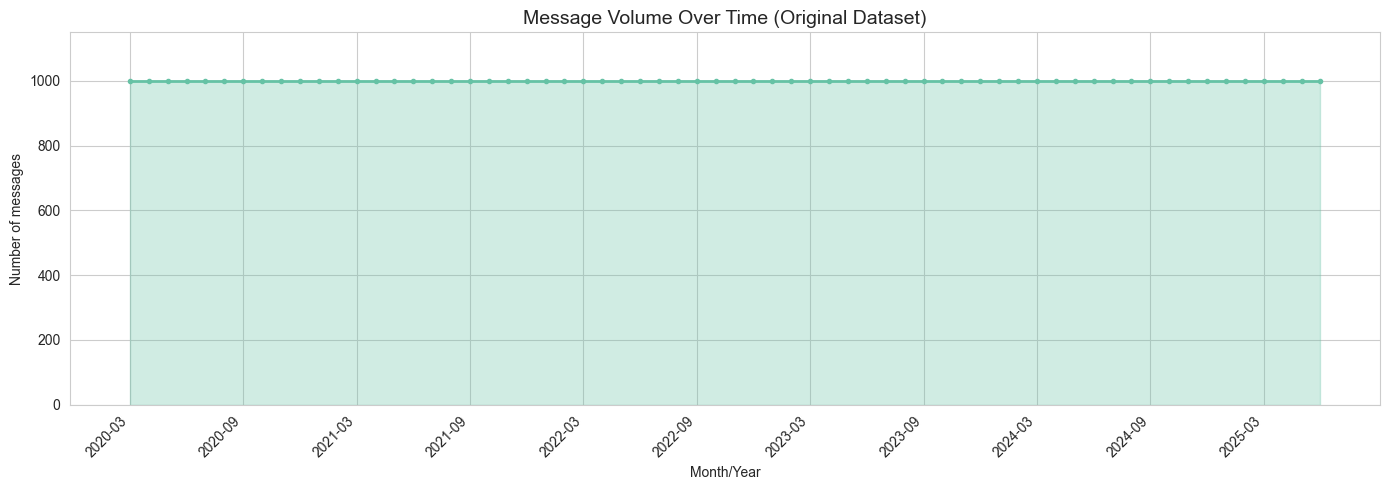

Temporal range: 2020-03 to 2025-06 (64 months)
Messages per month: min=1000, max=1000, mean=1000

⚠ The dataset uses time-bin stratified sampling (1,000 msgs/month).
  The uniform distribution does NOT reflect real-world message volume.


In [25]:
# Temporal distribution\n",
df['date_dt'] = pd.to_datetime(df['date_parsed'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
df['year_month'] = df['date_dt'].dt.to_period('M')

temporal = df.groupby('year_month').size()

fig, ax = plt.subplots(figsize=(14, 5))
x_labels = [str(p) for p in temporal.index]
ax.fill_between(range(len(temporal)), temporal.values, alpha=0.3, color='#66c2a5')
ax.plot(range(len(temporal)), temporal.values, color='#66c2a5', linewidth=2, marker='o', markersize=3)
ax.set_title('Message Volume Over Time (Original Dataset)', fontsize=14)
ax.set_xlabel('Month/Year')
ax.set_ylabel('Number of messages')
# Show every 6th label
step = 6
ax.set_xticks(range(0, len(temporal), step))
ax.set_xticklabels([x_labels[i] for i in range(0, len(temporal), step)], rotation=45, ha='right')
ax.set_ylim(0, temporal.max() * 1.15)
plt.tight_layout()
plt.savefig('figures/01_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Temporal range: {temporal.index[0]} to {temporal.index[-1]} ({len(temporal)} months)')
print(f'Messages per month: min={temporal.min()}, max={temporal.max()}, mean={temporal.mean():.0f}')
print(f'\n⚠ The dataset uses time-bin stratified sampling (1,000 msgs/month).')
print(f'  The uniform distribution does NOT reflect real-world message volume.')

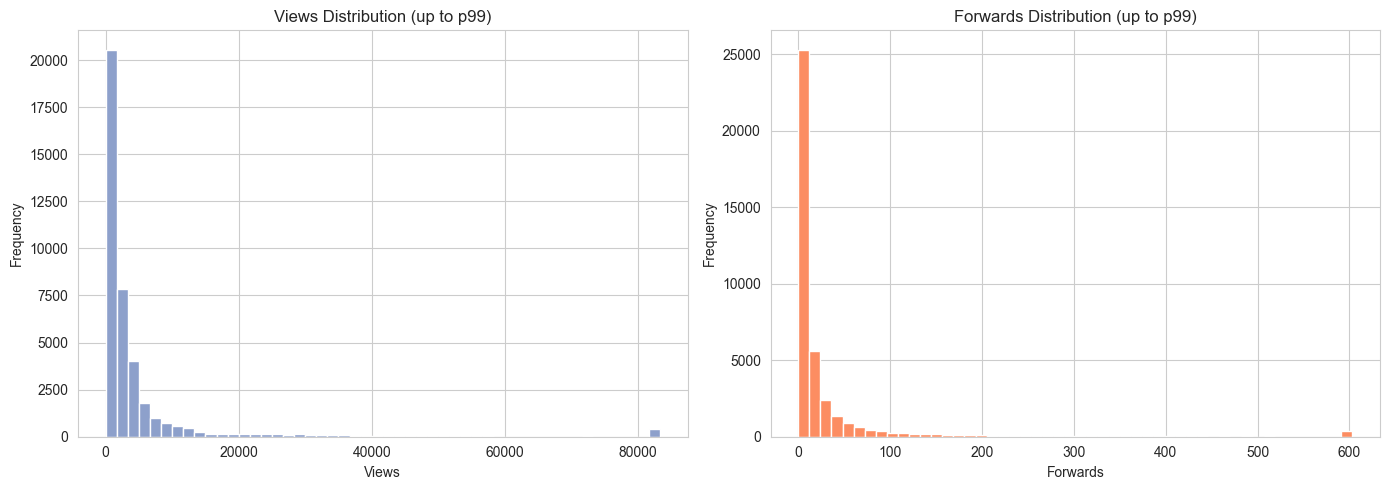

Views  — mean: 6495, median: 1572, max: 11,788,950.0
Forwards — mean: 40.9, median: 7, max: 32,637.0


In [26]:
# Engagement distributions (views and forwards)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Views (clipped at p99 to handle skewness)
df['views'].clip(upper=df['views'].quantile(0.99)).hist(
    bins=50, ax=axes[0], color='#8da0cb', edgecolor='white'
)
axes[0].set_title('Views Distribution (up to p99)', fontsize=12)
axes[0].set_xlabel('Views')
axes[0].set_ylabel('Frequency')

# Forwards
df['n_forwards'].clip(upper=df['n_forwards'].quantile(0.99)).hist(
    bins=50, ax=axes[1], color='#fc8d62', edgecolor='white'
)
axes[1].set_title('Forwards Distribution (up to p99)', fontsize=12)
axes[1].set_xlabel('Forwards')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('figures/01_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Views  — mean: {df['views'].mean():.0f}, median: {df['views'].median():.0f}, max: {df['views'].max():,}")
print(f"Forwards — mean: {df['n_forwards'].mean():.1f}, median: {df['n_forwards'].median():.0f}, max: {df['n_forwards'].max():,}")

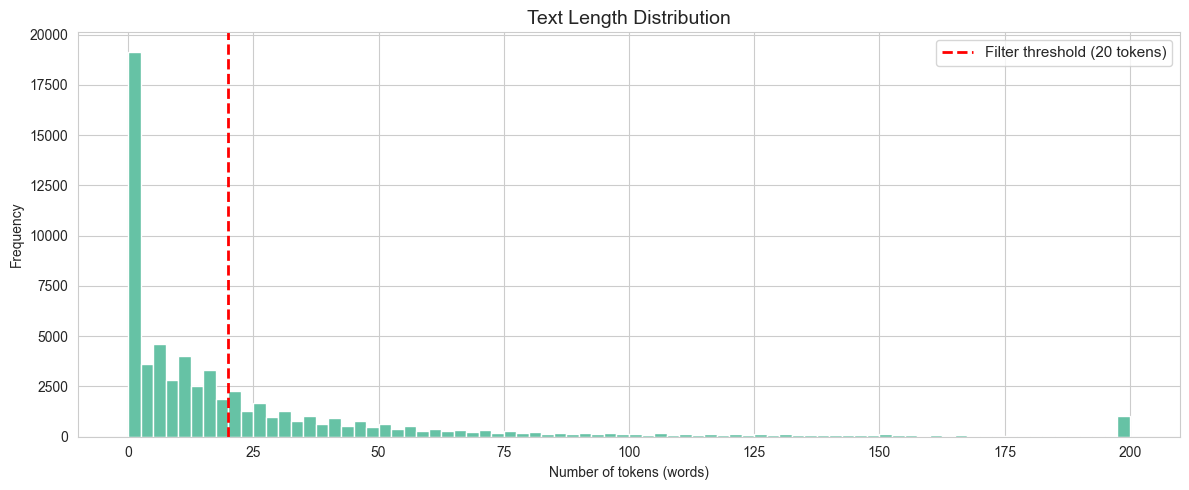

Total messages: 64,000
Messages with non-null text: 52,624
Messages with >= 20 tokens: 22,069


In [27]:
# Text length distribution (in tokens)
df['n_tokens'] = df['text_content'].fillna('').str.split().str.len()

fig, ax = plt.subplots(figsize=(12, 5))
df['n_tokens'].clip(upper=200).hist(bins=80, ax=ax, color='#66c2a5', edgecolor='white')
ax.axvline(x=20, color='red', linestyle='--', linewidth=2, label='Filter threshold (20 tokens)')
ax.set_title('Text Length Distribution', fontsize=14)
ax.set_xlabel('Number of tokens (words)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figures/01_token_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total messages: {len(df):,}")
print(f"Messages with non-null text: {df['text_content'].notna().sum():,}")
print(f"Messages with >= 20 tokens: {(df['n_tokens'] >= 20).sum():,}")

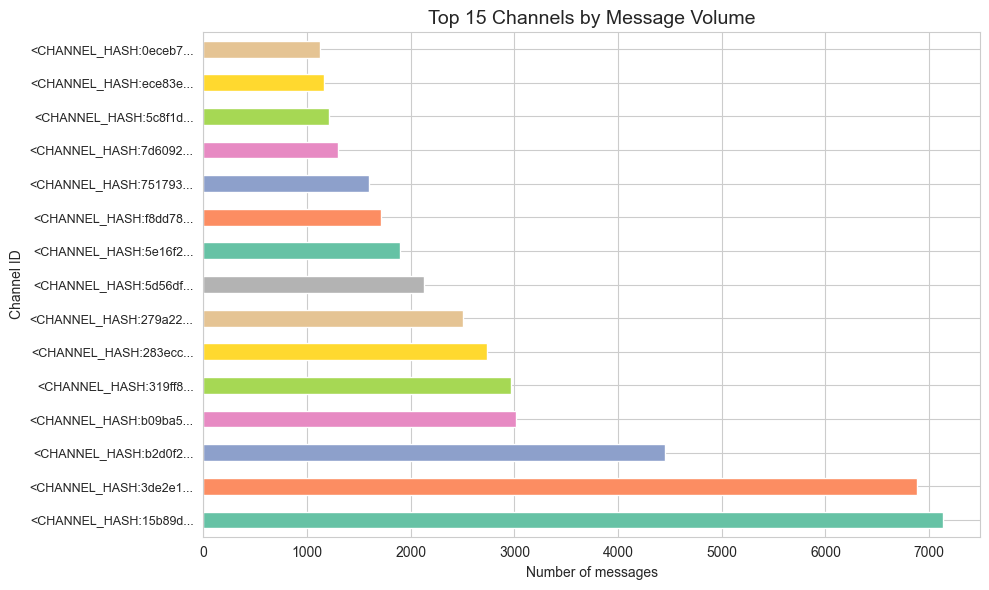

In [28]:
# Top channels by volume
top_channels = df['channel_id'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_channels.plot(kind='barh', ax=ax, color=sns.color_palette('Set2', 15))
ax.set_title('Top 15 Channels by Message Volume', fontsize=14)
ax.set_xlabel('Number of messages')
ax.set_ylabel('Channel ID')
# Truncate labels for readability
labels = [l.get_text()[:20] + '...' if len(l.get_text()) > 20 else l.get_text() for l in ax.get_yticklabels()]
ax.set_yticklabels(labels, fontsize=9)
plt.tight_layout()
plt.savefig('figures/01_top_channels.png', dpi=150, bbox_inches='tight')
plt.show()

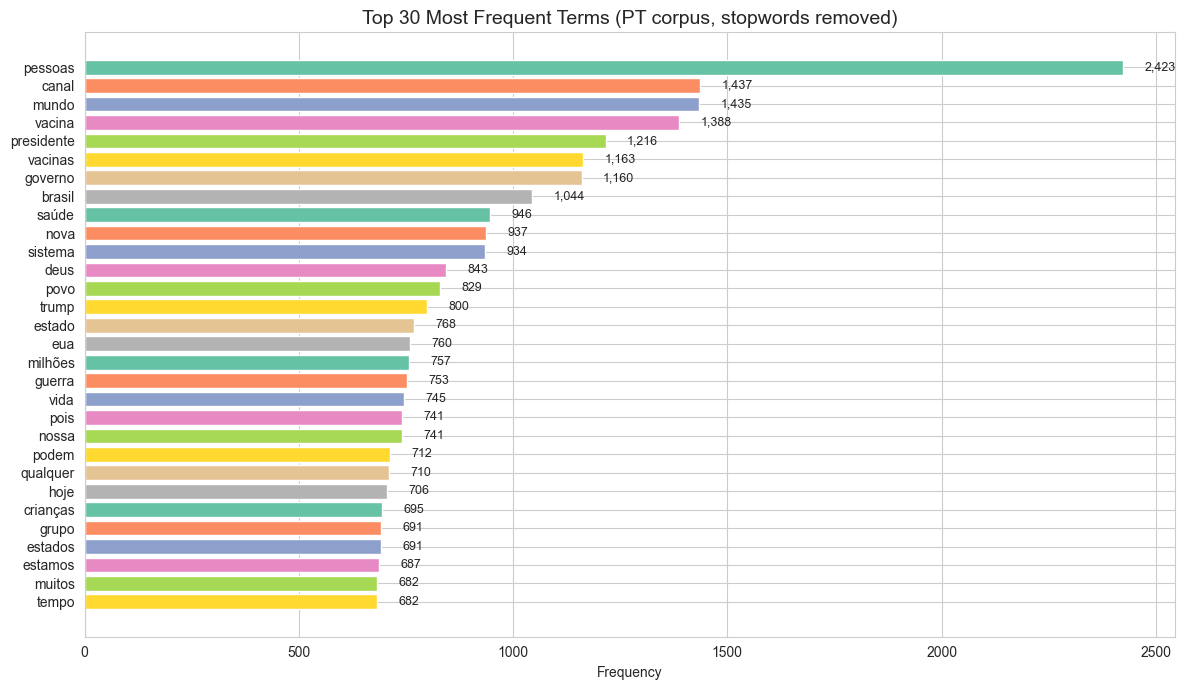

Total unique terms (after filtering): 48,957
Total word occurrences: 503,747


In [29]:
# Basic Portuguese stopwords list (Updated to filter common verbs and pronouns)
PT_STOPWORDS = set("""
a as ao aos à às ante após até com como contra da das de desde do dos e é ela elas ele eles em
entre era essa essas esse esses esta estas este estes eu foi for foram há isso isto já lhe lhes
me meu minha muito na nas não nas nem no nos nós o os ou para pela pelas pelo pelos por que
quem se sem ser seu seus só sua suas também te tem ter tu tua tuas um uma uns você vocês
mais mas foi foi ser ter está são foi pode seu sua seus suas nos das dos pela pelo
sobre ainda bem dia aqui então quando onde muito como mais já depois só até porque
entre todo toda todos todas outro outra outros outras mesmo mesma mesmos mesmas
cada vez parte assim antes onde através durante entre contra sobre
grande parte forma tipo ano anos sempre ainda cada pra pro vai
estão estao foram será fazer era disse sendo diz você isso quem esse tudo essa nosso esta este
até sem muito também quando após agora apenas porque depois aqui nem bem enquanto tao vcs
""".split())

pt_texts = df[(df["language"] == "Portuguese") & (df["text_content"].notna()) & (df["n_tokens"] >= 20)]["text_content"]

# Tokenize and count
all_words = []
for text in pt_texts:
    words = text.lower().split()
    all_words.extend([w for w in words if w.isalpha() and len(w) > 2 and w not in PT_STOPWORDS])

word_freq = Counter(all_words)
top_terms = word_freq.most_common(30)

fig, ax = plt.subplots(figsize=(12, 7))
terms = [t[0] for t in top_terms]
counts = [t[1] for t in top_terms]
bars = ax.barh(range(len(terms)), counts, color=sns.color_palette("Set2", len(terms)))
ax.set_yticks(range(len(terms)))
ax.set_yticklabels(terms, fontsize=10)
ax.invert_yaxis()
ax.set_title("Top 30 Most Frequent Terms (PT corpus, stopwords removed)", fontsize=14)
ax.set_xlabel("Frequency")
for i, v in enumerate(counts):
    ax.text(v + 50, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/01_top_terms.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total unique terms (after filtering): {len(word_freq):,}")
print(f"Total word occurrences: {sum(word_freq.values()):,}")

## Filtering and Export


In [30]:
# Apply filters
df_filtered = df[
    (df['language'] == 'Portuguese') &
    (df['text_content'].notna()) &
    (df['n_tokens'] >= 20)
].copy()

print(f'Original dataset: {len(df):,} messages')
print(f'After filtering (PT + text + >= 20 tokens): {len(df_filtered):,} messages')
print(f'Reduction: {(1 - len(df_filtered)/len(df))*100:.1f}%')
print(f'\nis_vaccine_related distribution in the filtered set:')
print(df_filtered['is_vaccine_related'].value_counts(dropna=False))

Original dataset: 64,000 messages
After filtering (PT + text + >= 20 tokens): 17,712 messages
Reduction: 72.3%

is_vaccine_related distribution in the filtered set:
0.0    14603
1.0     3109
Name: is_vaccine_related, dtype: int64


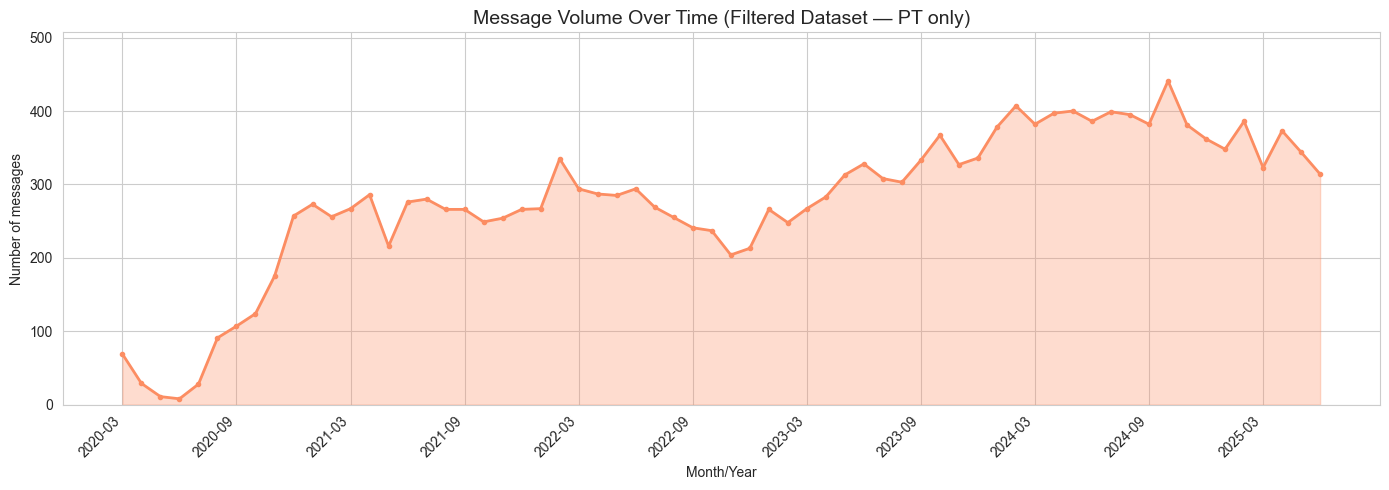

Filtered temporal range: 2020-03 to 2025-06
Messages per month: min=8, max=441, mean=277


In [31]:
# Temporal distribution of the filtered dataset
fig, ax = plt.subplots(figsize=(14, 5))
temporal_filt = df_filtered.groupby('year_month').size()
x_labels_filt = [str(p) for p in temporal_filt.index]
ax.fill_between(range(len(temporal_filt)), temporal_filt.values, alpha=0.3, color='#fc8d62')
ax.plot(range(len(temporal_filt)), temporal_filt.values, color='#fc8d62', linewidth=2, marker='o', markersize=3)
ax.set_title('Message Volume Over Time (Filtered Dataset — PT only)', fontsize=14)
ax.set_xlabel('Month/Year')
ax.set_ylabel('Number of messages')
step = 6
ax.set_xticks(range(0, len(temporal_filt), step))
ax.set_xticklabels([x_labels_filt[i] for i in range(0, len(temporal_filt), step)], rotation=45, ha='right')
ax.set_ylim(0, temporal_filt.max() * 1.15)
plt.tight_layout()
plt.savefig('figures/01_temporal_filtered.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Filtered temporal range: {temporal_filt.index[0]} to {temporal_filt.index[-1]}')
print(f'Messages per month: min={temporal_filt.min()}, max={temporal_filt.max()}, mean={temporal_filt.mean():.0f}')

In [32]:
# Qualitative text sample inspection
print('=== Sample texts from the filtered dataset ===\n')
for i, row in df_filtered.sample(5, random_state=42).iterrows():
    vax = 'Yes' if row['is_vaccine_related'] == 1 else ('No' if row['is_vaccine_related'] == 0 else 'N/A')
    print(f'[Vax: {vax} | Views: {row["views"]:,} | Fwd: {row["n_forwards"]}]')
    print(row['text_content'][:300])
    print('---')

=== Sample texts from the filtered dataset ===

[Vax: No | Views: 4,282.0 | Fwd: 41.0]
30 milhões de pessoas, ou 10% da população dos Estados Unidos, podem estar em perigo depois que um trem descarrilou em East Palestine, Ohio, que levou à liberação de produtos químicos tóxicos.

 “Basicamente, bombardeamos uma cidade com produtos químicos para que pudéssemos abrir uma ferrovia”, diss
---
[Vax: No | Views: 85.0 | Fwd: 0.0]
🇮🇱🇮🇷 Cartoon político num jornal israelita esta manhã. Os representantes do Irão estão prontos na linha de partida, à espera do sinal para atacar. 
. 
🔥 @<CHANNEL_HASH:ae1c52aceb99bc1beee6>
---
[Vax: No | Views: 2,556.0 | Fwd: 21.0]
🚜🇬🇷🛡⚔️🔥⏰️ Agricultores fazem aceiros para tentar conter um incêndio fora de controle que já dura dois dias em Alexandroupoli, na Grécia.

Um estado de emergência foi declarado e 13 aldeias foram evacuadas.
---
[Vax: No | Views: 677.0 | Fwd: 7.0]
🚨 Fauci “pode ser indiciado” por destruição de registros. 🔥🔥🔥

“Sen. Rand Paul, R-Ky., Argumen

In [33]:
# Save filtered dataset
cols_to_save = [
    'channel_id', 'message_id', 'date', 'date_parsed', 'date_dt',
    'text_content', 'n_tokens', 'language',
    'is_vaccine_related', 'n_forwards', 'views', 'reactions',
    'forward_from', 'reply_to', 'media_type'
]
df_filtered[cols_to_save].to_csv('aletheia_filtered.csv', index=False)
print(f'Filtered dataset saved: aletheia_filtered.csv ({len(df_filtered):,} rows)')

Filtered dataset saved: aletheia_filtered.csv (17,712 rows)


**Note:** The uniform volume across months is due to the dataset's sampling strategy (1,000 msgs/month). 
However, filtering for Portuguese only reveals a clear growth trend in message volume over time, which is more representative of the activity in these channels.